In [1]:
import numpy as np
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [8]:
iris_data = load_iris()  # load the iris dataset
x = iris_data.data
y = iris_data.target.reshape(-1, 1)  # convert data to a single column

In [9]:
y = keras.utils.to_categorical(y)  # one-hot
assert y.shape == (150, 3)

In [10]:
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.20)

In [12]:
model = Sequential()
model.add(Dense(10, activation='relu', input_dim=4))
model.add(Dense(10, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Adam optimizer with learning rate of 0.001
model.compile('adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
# Train the model
h = model.fit(train_x, train_y, batch_size=5, epochs=200)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3667 - loss: 1.9490
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3000 - loss: 1.5005
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2917 - loss: 1.3637
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3667 - loss: 1.2346
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3917 - loss: 1.1081
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4167 - loss: 1.0475
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4417 - loss: 1.0149
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6250 - loss: 0.8697
Epoch 9/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5667 - loss: 0.9011
Epoch 10/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5583 - loss: 0.8683
Epoch 11/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6333 - loss: 0.8344
Epoch 12/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accura

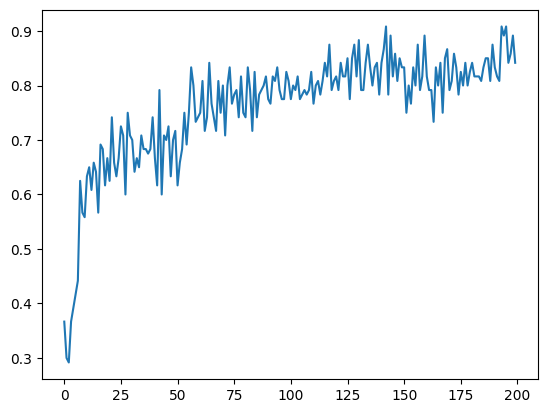

In [19]:
import matplotlib.pyplot as plt

plt.plot(h.history['accuracy']);

In [20]:
# Test on unseen data
result = model.evaluate(test_x, test_y)

print('Final test set loss: {:4f}'.format(result[0]))
print('Final test set accuracy: {:4f}'.format(result[1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9333 - loss: 0.1812
Final test set loss: 0.181180
Final test set accuracy: 0.933333
